In [359]:
# # ----- Logger ----- #
# from loguru import logger
# import time

# from contextlib import contextmanager

# logger.add("log.txt")

import time
import matplotlib.pyplot as plt
@contextmanager
def timer(name):
    t0 = time.time()
    yield
    logger.info(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [360]:
from collections import deque

In [361]:
class BFSSolver:
    """
        幅優先探索で貪欲的に確定する
        RESULT: 127.69
    """

    def __init__(self, N, total_oil_num):
        self.N = N
        self.grid_count = [[-1 for _ in range(N)] for _ in range(N)]
        self.grid_response = [[False for _ in range(N)] for _ in range(N)]
        self.grid_distance = [[0 for _ in range(N)] for _ in range(N)]
        for x in range(N):
            for y in range(N):
                self.grid_distance[y][x] = min(x + 1, y + 1, N - x, N - y)

        self.total_count = 0
        self.total_oil_nums = total_oil_num

        self.next_grids = set()

    def is_ok(self):
        return self.total_count == self.total_oil_nums

    def get_plus_grids(self):
        ret = []
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_count[y][x] == -1:
                    continue
                if self.grid_count[y][x] > 0:
                    ret.append((x, y))
        return ret

    def response(self, x, y, val):
        self.grid_count[y][x] = val
        self.grid_response[y][x] = True
        if val > 0:
            self.total_count += val
            for dx, dy in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                nx, ny = x + dx, y + dy
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if not self.grid_response[ny][nx]:
                    self.next_grids.add((nx, ny))
        self._update_distance(x, y)

    def get_next_search_point(self):
        if self.next_grids:
            return self.next_grids.pop()
        else:
            return self._get_far_point_from_wall()

    def _update_distance(self, x, y):
        searched = [[False for _ in range(self.N)] for _ in range(self.N)]
        self.grid_distance[y][x] = 0
        start = [(x, y)]
        search_q = deque(start)
        while search_q:
            px, py = search_q.popleft()
            searched[py][px] = True
            if searched[py][px]:
                continue
            for dx, dy in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                nx, ny = px + dx, py + dy
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if self.grid_distance[ny][nx] == 0 or searched[ny][nx]:
                    continue
                search_q.append((nx, ny))
                self.grid_distance[ny][nx] = min(
                    self.grid_distance[ny][nx], self.grid_distance[py][px] + 1
                )

    def _get_far_point_from_wall(self):
        max_val = max(max(l for l in self.grid_distance))
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_response[y][x]:
                    continue
                if self.grid_distance[y][x] == max_val:
                    return x, y

In [362]:
from pathlib import Path
import numpy as np

def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

class Env:

    def __init__(self, file_path):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2*M:]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))
        
        self.N = N
        self.M = M
        self.esp = ESP
        self.grids = GRID
        self.ans_grid = ANS_GRID

        self.total_size = sum(len(g) for g in self.grids)
        self._score = 0
        self.score = 10 ** 9
    
    def query1(self, coordinate):
        x, y = coordinate
        self._score += 1
        return self.ans_grid[y][x]

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for x, y in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        x = rng.normal(mu, sigma)
        self._score += 1 / np.sqrt(k)
        return max(0, round(x))

    def answer(self, coordinates):
        is_ok = self.total_size == sum(self.ans_grid[y][x] for x, y in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        return is_ok

In [363]:
def grid_print(g):
    for l in g:
        print(" ".join(map(str, l)))

In [364]:
scores = []
for test_num in range(100):

    try:
        env = Env(file_path = Path(f"./in/{test_num:0>4}.txt"))
        solver = BFSSolver(env.N, total_oil_num=env.total_size)
        for i in range(100000):
            x, y = solver.get_next_search_point()
            v = env.query1((x, y))
            solver.response(x, y, v)
            if solver.is_ok():
                env.answer(solver.get_plus_grids())
                break
    except Exception as e:
        print(e)
        scores.append(10**9)
    scores.append(env.score)

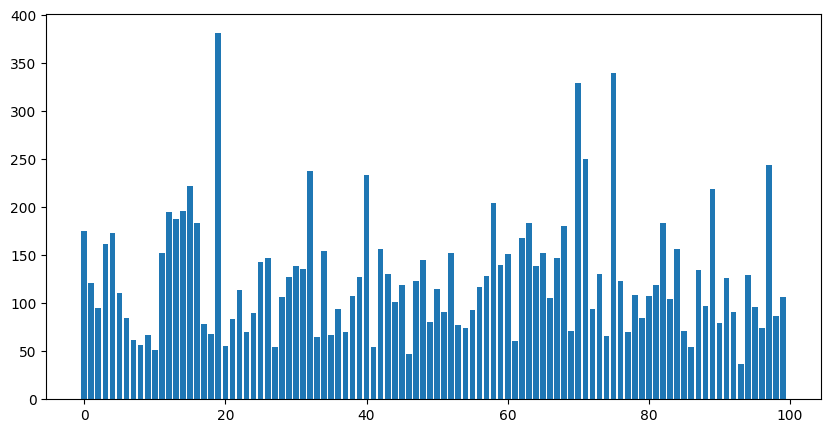

126.69


In [365]:
plt.figure(figsize=(10, 5))
plt.bar(list(range(len(scores))), scores)
plt.show()

print(sum(scores) / len(scores))